# Perceptron 1

## Inputs and weights

In [1]:
inputs = [35, 25]

In [2]:
type(inputs)

list

In [3]:
inputs[0]

35

In [4]:
inputs[1]

25

In [5]:
weights = [-0.8, 0.1]

## Sum function

In [6]:
def sum(inputs, weights):
  s = 0
  for i in range(2):
    #print(i)
    #print(inputs[i])
    #print(weights[i])
    s += inputs[i] * weights[i]
  return s

In [7]:
s = sum(inputs, weights)

In [8]:
s

-25.5

## Step function

In [9]:
def step_function(sum):
  if (sum >= 1):
    return 1
  return 0

## Final result

In [10]:
step_function(s)

0

Final predictions after training:
[[0.09431572]
 [0.8465572 ]
 [0.84655792]
 [0.20261236]]


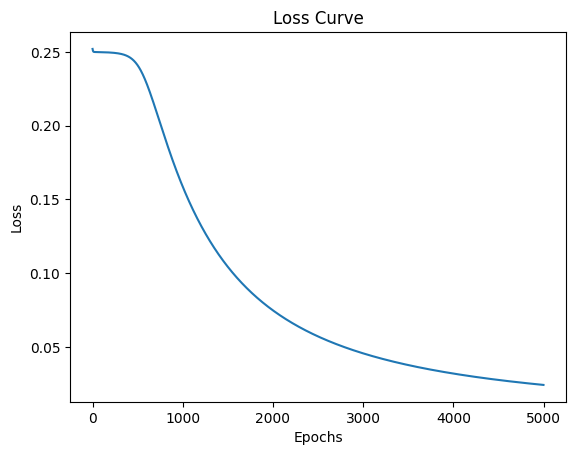

In [1]:
# Gradient Descent vs Backpropagation Demo
# ---------------------------------------
# This notebook demonstrates how backpropagation computes gradients
# and how gradient descent uses them to update weights.

import numpy as np
import matplotlib.pyplot as plt

# --- Helper Functions ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# --- Dataset (XOR problem) ---
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
y = np.array([[0],
              [1],
              [1],
              [0]])

# --- Initialize Weights ---
np.random.seed(42)
W1 = np.random.uniform(size=(2,2))
W2 = np.random.uniform(size=(2,1))

lr = 0.001
epochs = 1000
losses = []

# --- Training Loop ---
for epoch in range(epochs):
    # Forward pass
    hidden_input = np.dot(X, W1)
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2)
    final_output = sigmoid(final_input)

    # Loss (Mean Squared Error)
    loss = np.mean((y - final_output)**2)
    losses.append(loss)

    # --- Backpropagation (gradient calculation) ---
    error = y - final_output
    d_output = error * sigmoid_derivative(final_output)

    error_hidden = d_output.dot(W2.T)
    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    # --- Gradient Descent (weight update) ---
    W2 += hidden_output.T.dot(d_output) * lr
    W1 += X.T.dot(d_hidden) * lr

# --- Results ---
print("Final predictions after training:")
print(final_output)

# --- Plot Loss Curve ---
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()